In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_clean_csv(path, min_nonempty=3):
    """
    Automatically detects the first valid header row in messy CDC tables,
    drops Unnamed columns, and returns a clean DataFrame.
    """
    # Read first 10 rows to find a header row
    preview = pd.read_csv(path, header=None, nrows=10)
    
    # Find first row with enough non-empty values to be a header
    header_row = None
    for i, row in preview.iterrows():
        nonempty = row.count()
        if nonempty >= min_nonempty:
            header_row = i
            break
    
    # Load again using that row as header
    df = pd.read_csv(path, header=header_row)
    
    # Drop fully empty or "Unnamed" columns
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    print(f"✅ Loaded {path.split('/')[-1]} (using row {header_row} as header)")
    print(f"🧱 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    return df

In [2]:
adolescents = load_and_clean_csv("Vaccination_Coverage_Adolescents.csv")
display(adolescents.head())

✅ Loaded Vaccination_Coverage_Adolescents.csv (using row 3 as header)
🧱 Shape: 37 rows × 12 columns


,Vaccination coverage,2008,2010,2011,2012,2013\1,2014\1,2015\1,2016\1,2017\1,2018\1,2019\1
0,NaN,Percent of adolescents aged 13–17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Measles, mumps, rubella (2 doses or more)",89.3,90.5,91.1,91.4,89.6,90.7,90.7,90.9,92.1,91.9,91.9
2,Hepatitis B (3 doses or more),87.9,91.6,92.3,92.8,91.3,91.4,91.1,91.4,91.9,92.1,91.6
3,Varicella vaccine (2 doses or more) among thos...,34.1,58.1,68.3,74.9,78.5,81.0,83.1,85.6,88.6,89.6,90.6
4,Tdap (1 dose or more)\3,40.8,68.7,78.2,84.6,84.7,87.6,86.4,88.0,88.7,88.9,90.2


In [3]:
# Convert potential numeric-looking columns to numbers
adolescents_clean = adolescents.copy()
adolescents_clean = adolescents_clean.apply(lambda col: pd.to_numeric(col, errors="coerce"))

# Keep only columns that have at least one value between 0 and 100 (percentages)
adolescents_clean = adolescents_clean.loc[:, adolescents_clean.apply(lambda c: c.between(0, 100).any())]

print("Columns retained as numeric (0–100% range):")
print(list(adolescents_clean.columns))

Columns retained as numeric (0–100% range):
['2008', '2010', '2011', '2012', '2013\\1', '2014\\1', '2015\\1', '2016\\1', '2017\\1', '2018\\1', '2019\\1']


In [4]:
# Summary of cleaned columns
display(adolescents_clean.describe())

# Missing values
print("\nMissing values per column:")
print(adolescents_clean.isnull().sum())

,2008,2010,2011,2012,2013\1,2014\1,2015\1,2016\1,2017\1,2018\1,2019\1
count,13.000000,13.000000,14.000000,14.000000,14.000000,14.000000,14.000000,16.000000,16.00000,16.000000,9.000000
mean,67.192308,74.346154,71.828571,74.664286,73.421429,76.057143,75.921429,72.768750,74.13750,72.718750,68.544444
std,27.828207,20.350824,26.996251,25.903953,23.696257,22.746622,21.839808,22.447738,22.06765,23.137652,27.901618
min,17.900000,32.000000,1.300000,6.800000,13.400000,21.600000,28.100000,31.500000,34.80000,32.100000,26.600000
25%,41.800000,58.100000,62.075000,68.675000,66.250000,64.375000,62.100000,53.325000,52.57500,48.925000,51.800000
50%,87.900000,89.100000,81.750000,87.150000,85.750000,88.200000,87.500000,86.800000,88.65000,87.650000,88.900000
75%,91.100000,91.200000,91.850000,92.300000,88.875000,91.225000,90.650000,90.375000,91.52500,91.100000,90.600000
max,93.800000,92.500000,93.500000,93.300000,91.300000,93.400000,92.300000,91.400000,92.30000,92.500000,91.900000



Missing values per column:
2008      24
2010      24
2011      23
2012      23
2013\1    23
2014\1    23
2015\1    23
2016\1    21
2017\1    21
2018\1    21
2019\1    28
dtype: int64


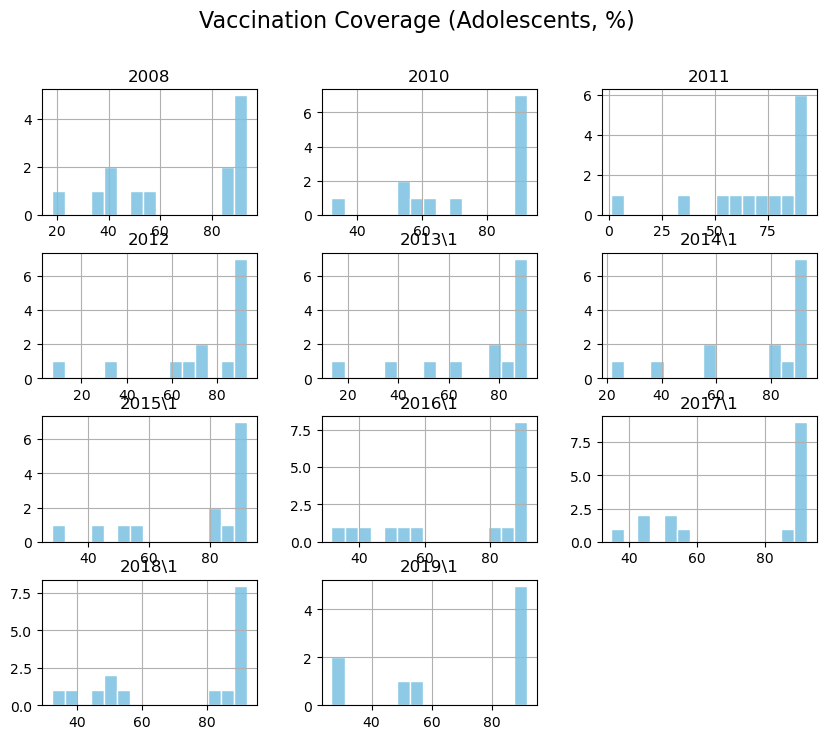

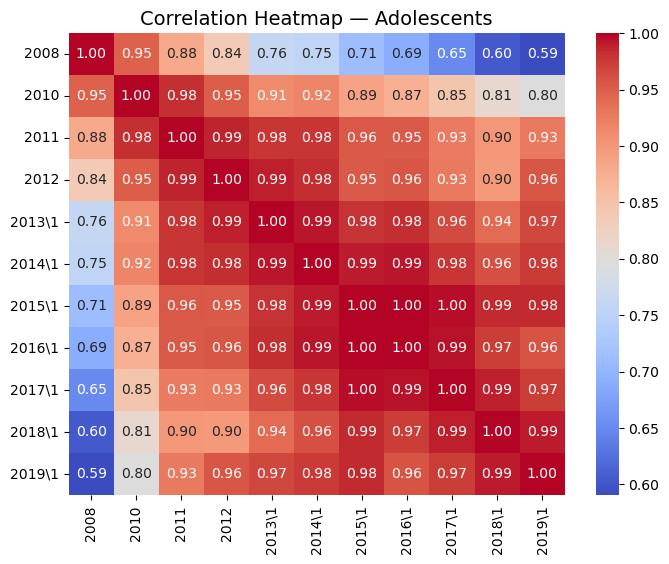

In [5]:
# Histogram plots for valid numeric columns
adolescents_clean.hist(figsize=(10, 8), bins=15, color="#8ecae6", edgecolor="white")
plt.suptitle("Vaccination Coverage (Adolescents, %)", fontsize=16)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(adolescents_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Adolescents", fontsize=14)
plt.show()

In [6]:
kindergartners = load_and_clean_csv("Vaccination_Coverage_and_Exemptions_among_Kindergartners.csv")
display(kindergartners.head())

✅ Loaded Vaccination_Coverage_and_Exemptions_among_Kindergartners.csv (using row 0 as header)
🧱 Shape: 8166 rows × 11 columns


,Vaccine/Exemption,Dose,Geography Type,Geography,School Year,Estimate (%),Population Size,Percent Surveyed,Footnotes,Number of Exemptions,Survey Type
0,Hepatitis B,NaN,States,Oklahoma,2015-16,96.4,54335.0,96.1,‡,NaN,Census
1,Hepatitis B,NaN,States,Oklahoma,2014-15,92.5,56967.0,95.9,‡,NaN,Census
2,Hepatitis B,NaN,States,Oklahoma,2013-14,97.7,57377.0,71.3,NaN,NaN,Voluntary response
3,Hepatitis B,NaN,States,Oklahoma,2012-13,92.7,56943.0,95.5,NaN,NaN,Census
4,Hepatitis B,NaN,States,Oklahoma,2016-17,NaN,52184.0,0.0,‡.¶,NaN,Census


In [7]:
# Convert 'Estimate (%)' to numeric
kindergartners_clean = kindergartners.copy()
kindergartners_clean["Estimate (%)"] = (
    kindergartners_clean["Estimate (%)"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace("—", "")
    .str.strip()
)
kindergartners_clean["Estimate (%)"] = pd.to_numeric(kindergartners_clean["Estimate (%)"], errors="coerce")

print("After cleaning, numeric values found in 'Estimate (%)':")
print(kindergartners_clean["Estimate (%)"].describe())

After cleaning, numeric values found in 'Estimate (%)':
count    6754.000000
mean       62.816716
std        43.669854
min         0.000000
25%         2.800000
50%        92.000000
75%        95.600000
max       100.000000
Name: Estimate (%), dtype: float64


In [8]:
display(kindergartners_clean.describe(include="all"))

print("\nMissing values per column:")
print(kindergartners_clean.isnull().sum())

,Vaccine/Exemption,Dose,Geography Type,Geography,School Year,Estimate (%),Population Size,Percent Surveyed,Footnotes,Number of Exemptions,Survey Type
count,8166,4779,8166,8166,8166,6754.000000,7.032000e+03,5538.000000,4820,2224.000000,7037
unique,7,7,2,57,16,NaN,NaN,NaN,101,NaN,39
top,Exemption,Any Exemption,States,U.S. Median,2023-24,NaN,NaN,NaN,†,NaN,Census
freq,2530,853,7855,157,591,NaN,NaN,NaN,1086,NaN,4669
mean,NaN,NaN,NaN,NaN,NaN,62.816716,1.254737e+05,84.593247,NaN,1780.603867,NaN
std,NaN,NaN,NaN,NaN,NaN,43.669854,4.217604e+05,30.654229,NaN,7493.957764,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,5.432000e+03,0.000000,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.800000,2.308700e+04,91.900000,NaN,129.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,92.000000,5.697050e+04,98.700000,NaN,492.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,95.600000,8.880900e+04,100.000000,NaN,1713.000000,NaN



Missing values per column:
Vaccine/Exemption          0
Dose                    3387
Geography Type             0
Geography                  0
School Year                0
Estimate (%)            1412
Population Size         1134
Percent Surveyed        2628
Footnotes               3346
Number of Exemptions    5942
Survey Type             1129
dtype: int64


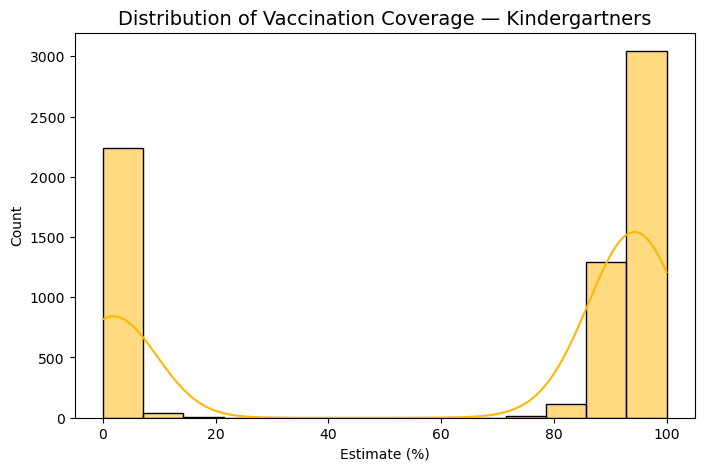

/var/folders/6x/4sj1_3c15yz56f3w3fmqwgzh0000gn/T/ipykernel_24453/3799889065.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Vaccine/Exemption", y="Estimate (%)", data=kindergartners_clean, palette="pastel")


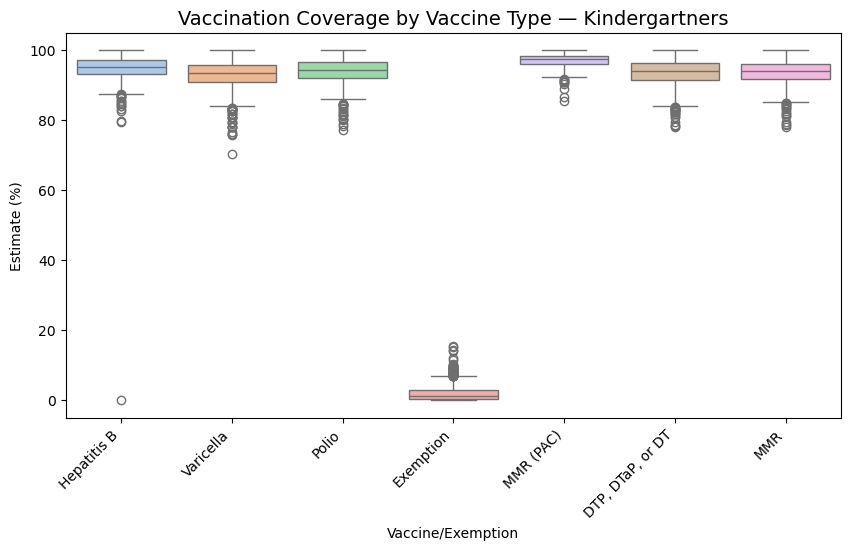

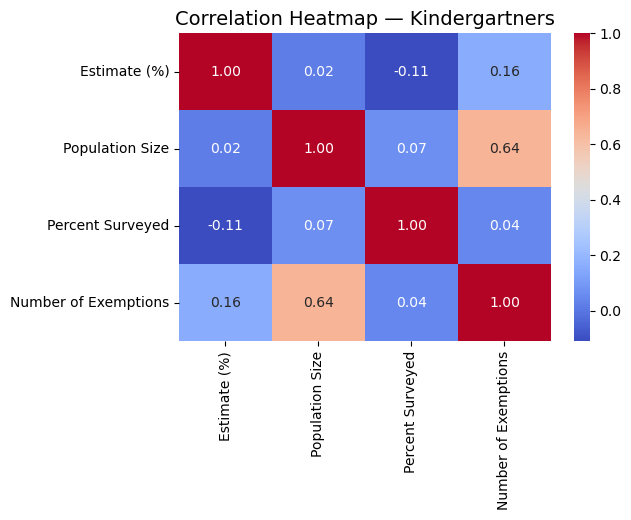

In [9]:
# Distribution of vaccination rates
plt.figure(figsize=(8, 5))
sns.histplot(kindergartners_clean["Estimate (%)"], kde=True, color="#ffb703")
plt.title("Distribution of Vaccination Coverage — Kindergartners", fontsize=14)
plt.xlabel("Estimate (%)")
plt.show()

# Categorical breakdown by Vaccine/Exemption
plt.figure(figsize=(10, 5))
sns.boxplot(x="Vaccine/Exemption", y="Estimate (%)", data=kindergartners_clean, palette="pastel")
plt.xticks(rotation=45, ha="right")
plt.title("Vaccination Coverage by Vaccine Type — Kindergartners", fontsize=14)
plt.show()

# Correlation heatmap
numeric_cols = kindergartners_clean.select_dtypes(include=np.number)
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Kindergartners", fontsize=14)
plt.show()

In [10]:
upto24 = load_and_clean_csv("Vaccination_Coverage_Up_to_24_Months.csv")
display(upto24.head())

✅ Loaded Vaccination_Coverage_Up_to_24_Months.csv (using row 4 as header)
🧱 Shape: 197 rows × 8 columns


,Characteristic,2010,2011,2012,2013,2014,2015,2016
0,Combined 7-vaccine series\1,Percent of children vaccinated by age 24 months,NaN,NaN,NaN,NaN,NaN,NaN
1,Total,65.9,67.7,69.0,68.3,68.5,68.3,69.7
2,Not Hispanic or Latino\2:,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,White only,67.1,69.2,70.3,69.6,70.0,68.6,71.4
4,Black or African American only,63.8,61.4,63.2,62.8,64.7,63.9,64.0


In [11]:
# Convert text columns to numeric where possible
upto24_clean = upto24.copy()
upto24_clean = upto24_clean.apply(lambda col: pd.to_numeric(col, errors="coerce"))

# Keep likely percentage columns (0–100)
upto24_clean = upto24_clean.loc[:, upto24_clean.apply(lambda c: c.between(0, 100).any())]

print("Columns retained as numeric (0–100% range):")
print(list(upto24_clean.columns))

Columns retained as numeric (0–100% range):
['2010', '2011', '2012', '2013', '2014', '2015', '2016']


In [12]:
display(upto24_clean.describe())

print("\nMissing values per column:")
print(upto24_clean.isnull().sum())

,2010,2011,2012,2013,2014,2015,2016
count,122.000000,128.000000,131.000000,126.000000,122.000000,124.000000,120.000000
mean,79.550820,80.742188,82.397710,81.189683,80.623770,81.364516,81.333333
std,10.807713,10.044198,9.837577,9.233078,9.068363,9.520147,9.169710
min,53.900000,54.500000,59.600000,58.500000,59.400000,60.400000,54.900000
25%,68.400000,72.200000,74.000000,74.150000,72.525000,74.800000,74.550000
50%,80.100000,81.650000,83.800000,81.800000,81.300000,81.900000,81.200000
75%,89.650000,89.900000,91.250000,90.075000,89.375000,90.325000,90.525000
max,96.300000,95.600000,97.700000,94.200000,94.700000,96.800000,93.800000



Missing values per column:
2010    75
2011    69
2012    66
2013    71
2014    75
2015    73
2016    77
dtype: int64


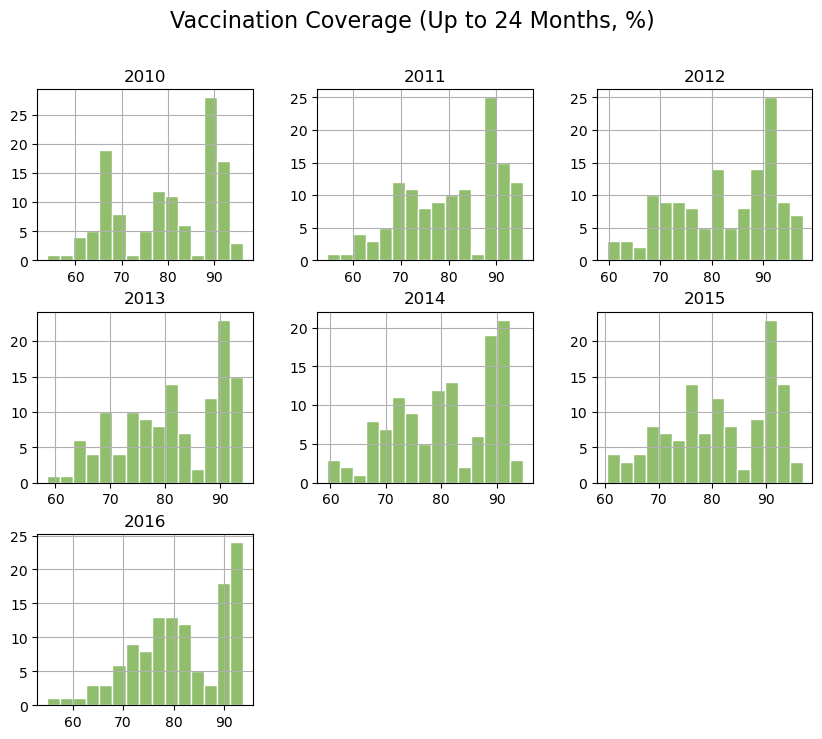

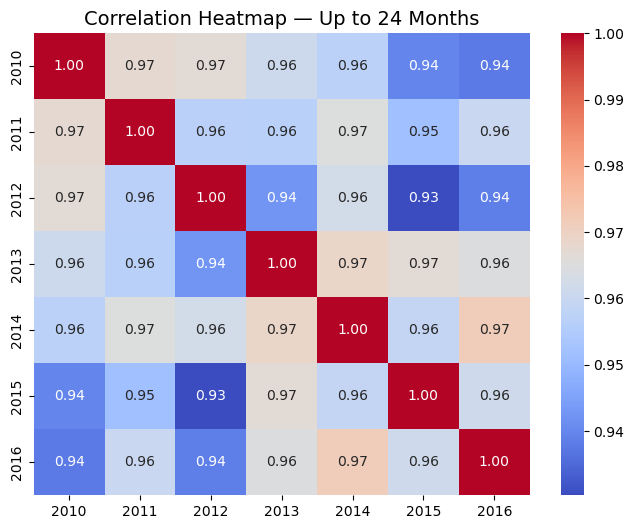

In [13]:
# Histograms for percentage columns
upto24_clean.hist(figsize=(10, 8), bins=15, color="#90be6d", edgecolor="white")
plt.suptitle("Vaccination Coverage (Up to 24 Months, %)", fontsize=16)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(upto24_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Up to 24 Months", fontsize=14)
plt.show()